<img src="udc1.png" alt="UDC"/>

# Notebook pour la classification d'images(déchets) avec JEPA. 

In [1]:
import outils
import numpy as np
import matplotlib.pyplot as plt
import os 
import pandas as pd

In [2]:
df = outils.Load_data.load_object("dataset2.zip")

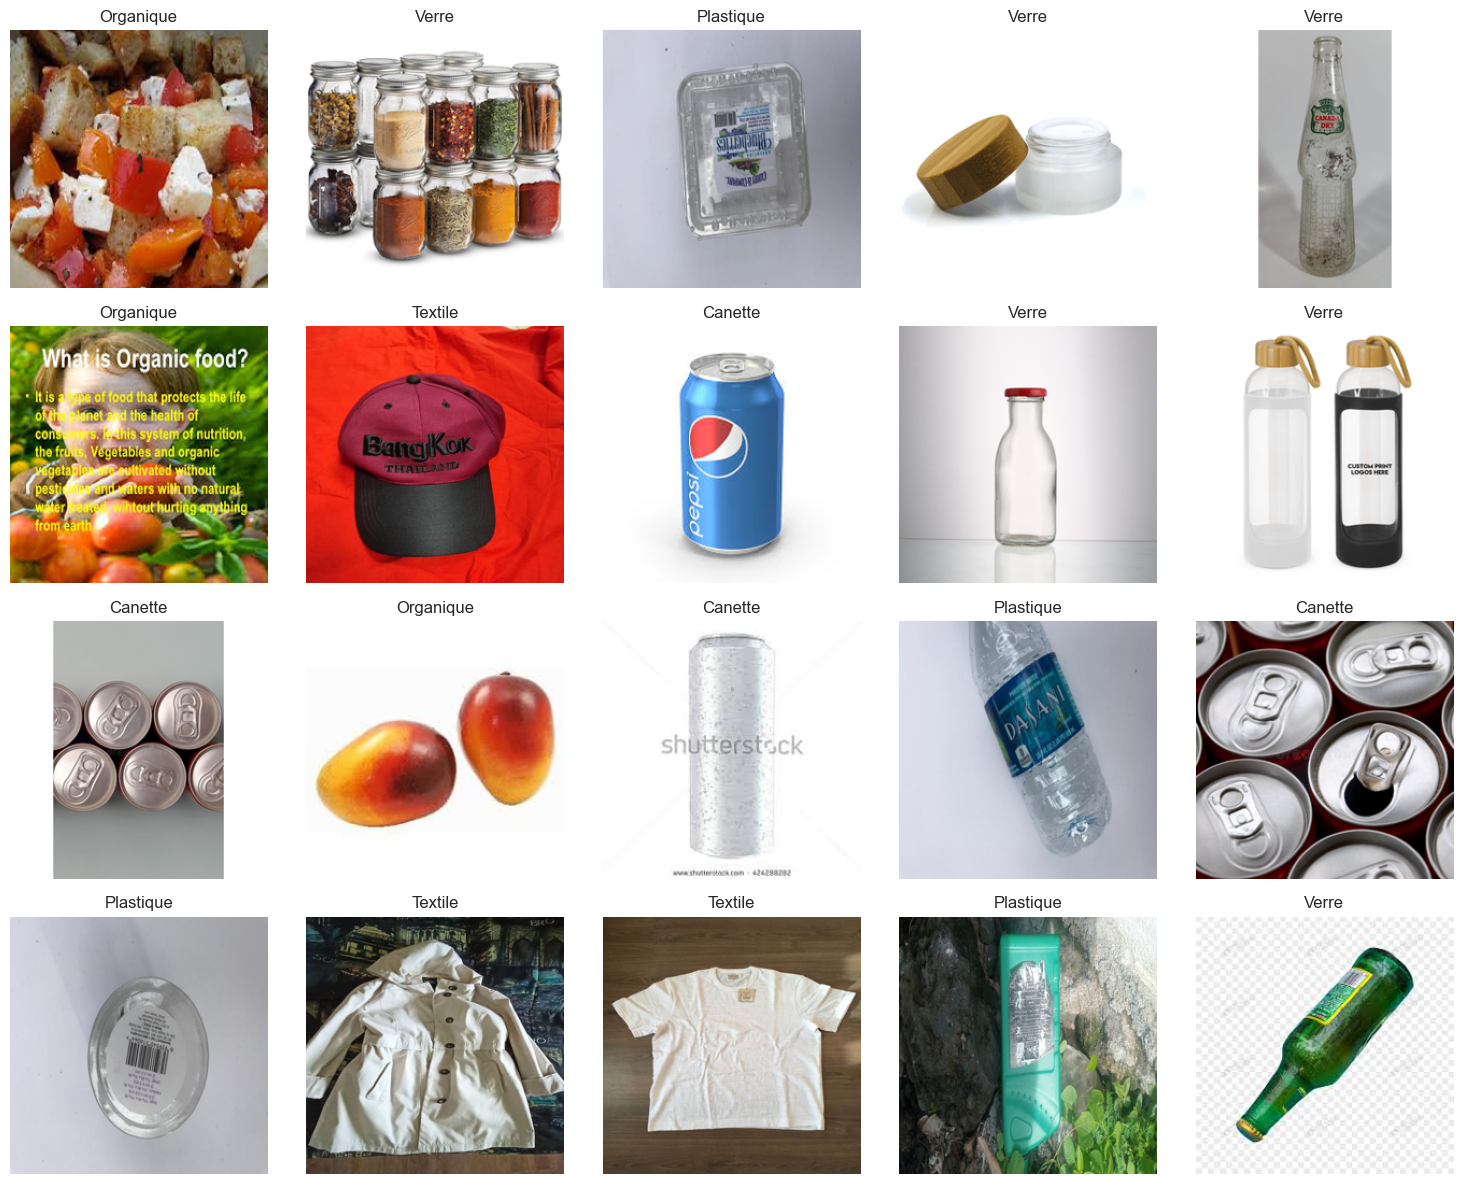

In [3]:
df.plot()

In [4]:
df.reshape(target_shape=(64, 64, 3))

Reshape en batch: 100%|██████████| 380/380 [00:18<00:00, 20.59it/s]


In [5]:
df.encodage()

Encodage effectué. Mapping: {'Canette': 0, 'Organique': 1, 'Plastique': 2, 'Textile': 3, 'Verre': 4}


In [6]:
(X_train, y_train), (X_test, y_test) = df.create_data(test_size=0.2)

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
train_datagen = ImageDataGenerator(
    rotation_range=5,      # Très faible
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    rescale=1./255
)
test_datagen =  ImageDataGenerator(rescale= 1. / 255)

In [9]:
train_generator = train_datagen.flow(X_train,y_train,batch_size=32)
test_generator  = test_datagen.flow(X_test,y_test,batch_size=32)

In [12]:
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam,SGD,RMSprop
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.callbacks import LearningRateScheduler,ModelCheckpoint,ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
import tensorflow as tf
from tensorflow.keras import layers, regularizers, Model, Input
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Dense, Dropout, Add, BatchNormalization, Input, Flatten
from keras.saving import register_keras_serializable

In [10]:
# Dimensions
IMG_HEIGHT = 64
IMG_WIDTH = 64
IMG_CHANNELS = 3
EMBED_DIM = 256           # Dimension de l'espace latent
NUM_CLASSES = 5
BATCH_SIZE = 64
EPOCHS_JEPA = 100          # Pré-entraînement auto-supervisé
EPOCHS_CLASS = 50         # Classification supervisée
EMA_DECAY = 0.99          # Pour l'encodeur cible

In [13]:
@register_keras_serializable()
def build_encoder(embed_dim=EMBED_DIM, input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    """
    Encodeur CNN basé sur l'architecture de l'utilisateur.
    Sortie : vecteur latent de dimension embed_dim.
    """
    inputs = tf.keras.Input(shape=input_shape, name='encoder_input')
    
    # Bloc 1: 64x64 → 32x32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Bloc 2: 32x32 → 16x16
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Bloc 3: 16x16 → 8x8
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Bloc 4: 8x8 → 4x4
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Bloc 5: 4x4 → 2x2
    x = layers.Conv2D(132, (2, 2), activation='relu', padding='same', kernel_regularizer=l2(0.001))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    # Aplatissement et projection
    x = layers.Flatten()(x)
    outputs = layers.Dense(embed_dim, activation='relu', name='latent')(x)
    
    return Model(inputs, outputs, name='encoder')

In [14]:
@register_keras_serializable()
def build_predictor(embed_dim=EMBED_DIM):
    """
    Prédicteur JEPA : prédit l'embedding cible à partir de l'embedding contextuel
    """
    inputs = tf.keras.Input(shape=(embed_dim,), name='predictor_input')
    x = layers.Dense(512, activation='relu', kernel_regularizer=l2(0.001))(inputs)
    x = layers.Dropout(0.1)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=l2(0.001))(x)
    outputs = layers.Dense(embed_dim, name='prediction')(x)
    return Model(inputs, outputs, name='predictor')

In [15]:
@register_keras_serializable()
def build_classifier(embed_dim=EMBED_DIM, num_classes=NUM_CLASSES):
    """
    Tête de classification linéaire (pour linear probing)
    """
    inputs = tf.keras.Input(shape=(embed_dim,), name='classifier_input')
    x = layers.Dense(64, activation='relu', kernel_regularizer=l2(0.001))(inputs)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, name='logits')(x)
    return Model(inputs, outputs, name='classifier')

In [16]:
@register_keras_serializable()
class JEPA_Model(tf.keras.Model):
    """
    Modèle JEPA unifié avec support complet de sauvegarde/chargement
    """
    
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES, **kwargs):
        super().__init__(**kwargs)
        
        self.embed_dim = embed_dim
        self.num_classes = num_classes
        
        # Construire les sous-modèles
        self.encoder = build_encoder(embed_dim)
        self.target_encoder = build_encoder(embed_dim)
        self.predictor = build_predictor(embed_dim)
        self.classifier = build_classifier(embed_dim, num_classes)
        
        # Initialiser l'encodeur cible
        self._init_target_encoder()
        
        # Métriques
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.acc_metric = tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
        self.jepa_loss_tracker = tf.keras.metrics.Mean(name="jepa_loss")
        self.cls_loss_tracker = tf.keras.metrics.Mean(name="cls_loss")
    
    def _init_target_encoder(self):
        """Initialise l'encodeur cible avec les poids de l'encodeur source"""
        for w, tw in zip(self.encoder.weights, self.target_encoder.weights):
            tw.assign(w)
        self.target_encoder.trainable = False
    
    def _update_target_encoder(self, decay=EMA_DECAY):
        """Met à jour l'encodeur cible par EMA"""
        for w, tw in zip(self.encoder.weights, self.target_encoder.weights):
            tw.assign(decay * tw + (1 - decay) * w)
    
    def compute_loss(self, logits, anomaly_score, labels, lambda_cls=1.0, lambda_jepa=0.5):
        loss_cls = tf.reduce_mean(
            tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True)
        )
        loss_jepa = tf.reduce_mean(anomaly_score)
        return lambda_cls * loss_cls + lambda_jepa * loss_jepa
    
    def call(self, x, training=False):
        # Encodage
        z = self.encoder(x, training=training)
        
        # Prédiction JEPA
        z_pred = self.predictor(z, training=training)
        
        # Encodage cible (stop_gradient)
        z_target = tf.stop_gradient(self.target_encoder(x, training=training))
        
        # Classification
        logits = self.classifier(z, training=training)
        
        # Score d'anomalie
        anomaly_score = tf.norm(z_pred - z_target, axis=1)
        
        return logits, anomaly_score
    
    def train_step(self, data):
        images, labels = data
        
        with tf.GradientTape() as tape:
            logits, anomaly_score = self(images, training=True)
            loss = self.compute_loss(logits, anomaly_score, labels)
        
        train_vars = self.trainable_variables
        grads = tape.gradient(loss, train_vars)
        self.optimizer.apply_gradients(zip(grads, train_vars))
        
        self._update_target_encoder()
        
        self.loss_tracker.update_state(loss)
        self.acc_metric.update_state(labels, logits)
        self.jepa_loss_tracker.update_state(tf.reduce_mean(anomaly_score))
        self.cls_loss_tracker.update_state(
            tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True))
        )
        
        return {
            "loss": self.loss_tracker.result(),
            "accuracy": self.acc_metric.result(),
            "jepa_loss": self.jepa_loss_tracker.result(),
            "cls_loss": self.cls_loss_tracker.result()
        }
    
    def test_step(self, data):
        images, labels = data
        logits, anomaly_score = self(images, training=False)
        loss = self.compute_loss(logits, anomaly_score, labels)
        
        self.loss_tracker.update_state(loss)
        self.acc_metric.update_state(labels, logits)
        self.jepa_loss_tracker.update_state(tf.reduce_mean(anomaly_score))
        self.cls_loss_tracker.update_state(
            tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True))
        )
        
        return {
            "loss": self.loss_tracker.result(),
            "accuracy": self.acc_metric.result(),
            "jepa_loss": self.jepa_loss_tracker.result(),
            "cls_loss": self.cls_loss_tracker.result()
        }
    
    @property
    def metrics(self):
        return [self.loss_tracker, self.acc_metric, self.jepa_loss_tracker, self.cls_loss_tracker]
    
    # ============================================
    # MÉTHODES POUR LA SAUVEGARDE/CHARGEMENT
    # ============================================
    
    def get_config(self):
        """Retourne la configuration pour la sauvegarde"""
        config = super().get_config()
        config.update({
            "embed_dim": self.embed_dim,
            "num_classes": self.num_classes
        })
        return config
    
    @classmethod
    def from_config(cls, config):
        """Reconstruit le modèle à partir de la configuration"""
        return cls(**config)


In [17]:
model = JEPA_Model(embed_dim=256, num_classes=5)

In [18]:
model.summary()

Model: "jepa__model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ (None, 256)            │       445,908 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Functional)            │ (None, 256)            │       445,908 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictor (Functional)          │ (None, 256)            │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classifier (Functional)         │ (None, 5)              │        16,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,237,293 (4.72 MB)

 Trainable params: 790,417 (3.02 MB)

 Non-trainable params: 446,876 (1.70 MB)

In [19]:
def load_model(filepath):
   
    custom_objects = {
        'JEPA_Model': JEPA_Model,
        'build_encoder': build_encoder,
        'build_predictor': build_predictor,
        'build_classifier': build_classifier
    }
    
   
    model = tf.keras.models.load_model(
        filepath,
        custom_objects=custom_objects,
        compile=False
    )
    
    return model


In [20]:
def format_time(seconds):
    """Convertit un temps en secondes en format jours:heures:minutes:secondes"""
    days = int(seconds // 86400)
    hours = int((seconds % 86400) // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    
    if days > 0:
        return f"{days}j {hours}h {minutes}m {secs}s"
    elif hours > 0:
        return f"{hours}h {minutes}m {secs}s"
    elif minutes > 0:
        return f"{minutes}m {secs}s"
    else:
        return f"{secs}s"

In [21]:
import time

initial_learning_rate = 1e-3

# Callbacks avec modes explicites
param_surv_app1 = ModelCheckpoint(
    "model_jepa_cls_1.keras",
    monitor="val_accuracy",
    verbose=1,
    save_best_only=True,
    mode='max'
)

param_surv_app2 = EarlyStopping(
    monitor='val_loss',
    patience=30,
    verbose=1,
    restore_best_weights=True,
    mode='min'
)

param_surv_app3 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=20,
    verbose=1,
    mode='min'
)

# Compilation
model.compile(optimizer=RMSprop(learning_rate=initial_learning_rate))

# Entraînement
start_time = time.time()

historique = model.fit(
    train_generator,
    epochs=300,
    validation_data=test_generator,
    callbacks=[param_surv_app1, param_surv_app2, param_surv_app3]
)

end_time = time.time()
elapsed = end_time - start_time
print(f"Temps d'entraînement : {format_time(elapsed)}")


C:\Users\hp\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/300
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.4530 - cls_loss: 1.4023 - jepa_loss: 1.4158 - loss: 2.1102
Epoch 1: val_accuracy improved from None to 0.42175, saving model to model_jepa_cls_1.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 63s 194ms/step - accuracy: 0.5021 - cls_loss: 1.2576 - jepa_loss: 1.8878 - loss: 2.2015 - val_accuracy: 0.4217 - val_cls_loss: 1.9174 - val_jepa_loss: 4.7556 - val_loss: 4.2952 - learning_rate: 0.0010
Epoch 2/300
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.5532 - cls_loss: 1.1129 - jepa_loss: 5.4702 - loss: 3.8480
Epoch 2: val_accuracy improved from 0.42175 to 0.57990, saving model to model_jepa_cls_1.keras
304/304 ━━━━━━━━━━━━━━━━━━━━ 54s 179ms/step - accuracy: 0.5630 - cls_loss: 1.1030 - jepa_loss: 7.3090 - loss: 4.7574 - val_accuracy: 0.5799 - val_cls_loss: 1.1179 - val_jepa_loss: 12.2033 - val_loss: 7.2195 - learning_rate: 0.0010
Epoch 3/300
304/304 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.5796 - cls_loss: 1.0529 - j

: 

: 

In [39]:
historique

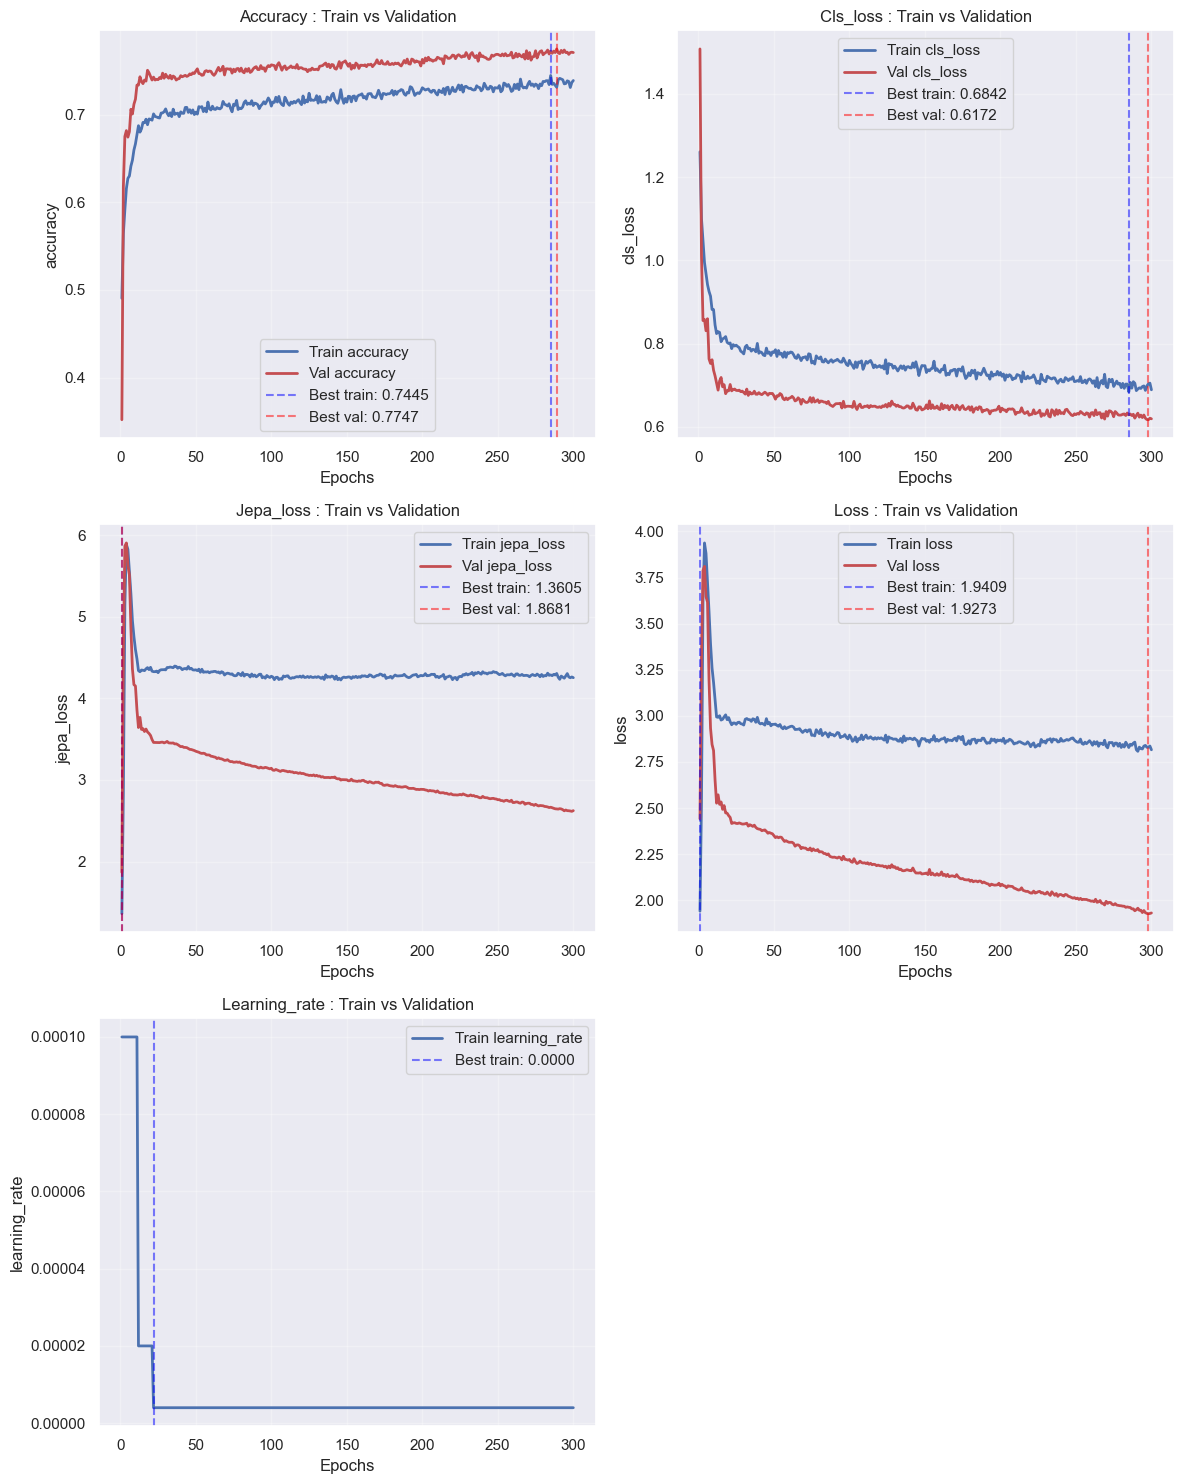

Historique sauvegardé : training_results\plot_cls_jepa_1_history.json
CSV sauvegardé : training_results\plot_cls_jepa_1_history.csv


In [22]:
outils.plot_result(historique,name_fig="plot_cls_jepa_1",register_plot=False)

In [23]:

from sklearn.metrics import confusion_matrix,classification_report,f1_score
import seaborn as sns



def evaluation(model, X_test, y_test, return_conf_mat=True, return_clss=True, labels=[]):
    # Prédictions
    predict_proba = model.predict(X_test)
    y_pred = np.argmax(predict_proba[0], axis=1)

    # Matrice de confusion
    conf_matrice = confusion_matrix(y_test, y_pred)

    if return_conf_mat:
        print("========================================== Confusion Matrix =====================================================")
        print(conf_matrice)
        f, ax = plt.subplots(figsize=(6, 5))
        conf_matrice_nor = conf_matrice.astype('float') / conf_matrice.sum(axis=1)[:, np.newaxis]
        sns.heatmap(conf_matrice_nor, annot=True, fmt=".2%", linewidths=.5, ax=ax,
                    xticklabels=labels, yticklabels=labels, cbar=False)
        plt.ylabel("True class")
        plt.xlabel("Predicted class")
        plt.title("Normalized Confusion Matrix")
        plt.show()

    if return_clss:
        print("========================================= Detailed Metrics =====================================================")
        # Rapport complet (inclut précision, rappel et f1-score par classe)
        report = classification_report(y_test, y_pred, target_names=labels, digits=4)
        print(report)

        # F1 macro et weighted
        f1_macro = f1_score(y_test, y_pred, average='macro')
        f1_weighted = f1_score(y_test, y_pred, average='weighted')

        print(f"Macro F1-score (unweighted): {f1_macro:.4f}")
        print(f"Weighted F1-score: {f1_weighted:.4f}")
    return y_pred

In [26]:
X_test = X_test.astype('float32') / 255.0

In [27]:
X_test.max(), X_test.min(), X_test.shape

(np.float32(1.0), np.float32(0.0), (2428, 64, 64, 3))

In [50]:
y_result = model.predict(X_test)

76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 252ms/step


76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step
========================================== Confusion Matrix =====================================================
[[251  12  28  25  23]
 [ 29 389  11  24  29]
 [ 70  15 304  48  57]
 [  6  21  10 517   1]
 [ 60  21  54  13 410]]


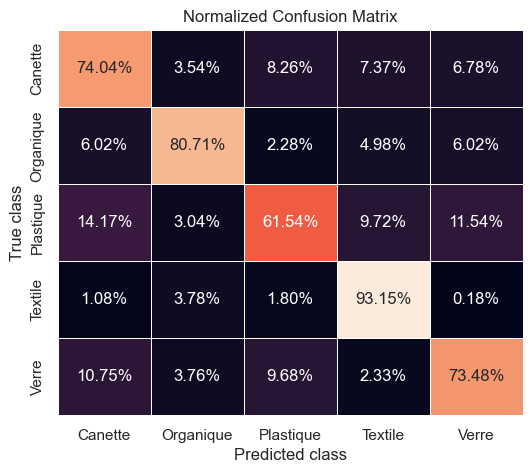

========================================= Detailed Metrics =====================================================
              precision    recall  f1-score   support

     Canette     0.6034    0.7404    0.6649       339
   Organique     0.8493    0.8071    0.8277       482
   Plastique     0.7469    0.6154    0.6748       494
     Textile     0.8246    0.9315    0.8748       555
       Verre     0.7885    0.7348    0.7607       558

    accuracy                         0.7706      2428
   macro avg     0.7625    0.7658    0.7606      2428
weighted avg     0.7745    0.7706    0.7692      2428

Macro F1-score (unweighted): 0.7606
Weighted F1-score: 0.7692


array([0, 4, 0, ..., 4, 3, 4], shape=(2428,))

In [28]:
evaluation(model=model, X_test=X_test, y_test=y_test, return_conf_mat=True, return_clss=True, labels=df.name_label_)

In [55]:
y_result[0].shape

(2428, 5)

In [23]:
X_test.shape

(2428, 64, 64, 3)

In [29]:
df_an = outils.Load_data.load_object("detect_anomalie.zip")

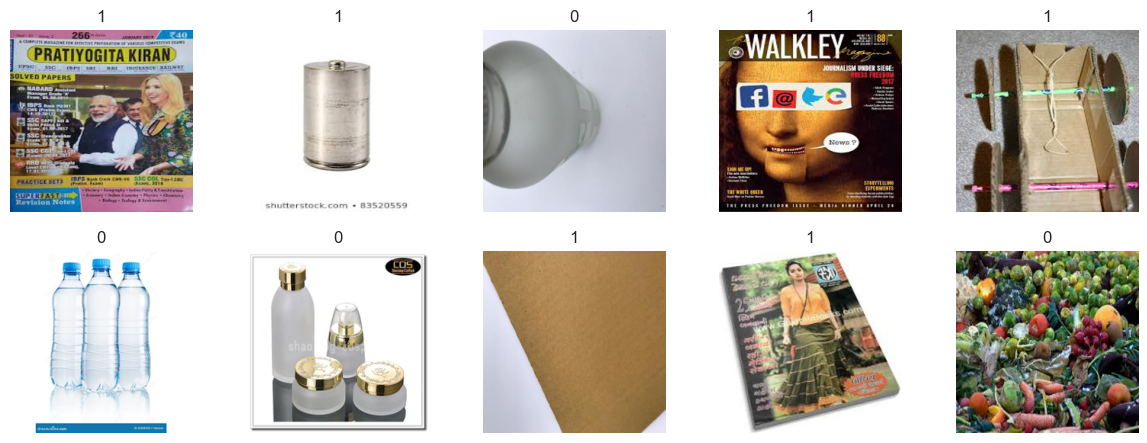

In [43]:
df_an.plot(view_code=True)

In [33]:
df_an.encodage()

In [46]:
df_an.reshape(target_shape=(64, 64, 3))

Reshape en batch: 100%|██████████| 125/125 [00:07<00:00, 16.27it/s]


In [47]:
(X_train_an, y_train_an), (_ , _) = df_an.create_data(test_size=0.00000000000001)

In [48]:
X_train_an.shape

(3999, 64, 64, 3)

In [ ]:
def compute_jepa_score(encoder, image):
    if len(image.shape) == 3:
        image = np.expand_dims(image, axis=0)
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(image)
        latent = encoder(image, training=False)
    
    # Jacobien
    jacobian = tape.jacobian(latent, image)
    
    # Reshape: (latent_dim, -1)
    jacobian = tf.reshape(jacobian, (latent.shape[-1], -1))
    
    # SVD et calcul du score
    s = tf.linalg.svd(jacobian, compute_uv=False)
    score = tf.reduce_sum(tf.math.log(s + 1e-6))
    
    return score.numpy()


In [64]:
from tqdm import tqdm
def compute_scores_batch(encoder, images, batch_size=32):
    scores = []
    n_images = len(images)
    
    for i in tqdm(range(0, n_images, batch_size), desc="Calcul des scores"):
        batch = images[i:min(i+batch_size, n_images)]
        for img in batch:
            score = compute_jepa_score(encoder, img)
            scores.append(score)
    
    return np.array(scores)

In [54]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import seaborn as sns

In [55]:
def find_optimal_threshold(scores_normal, scores_anomaly, metric='f1'):

    all_scores = np.concatenate([scores_normal, scores_anomaly])
    all_labels = np.concatenate([np.zeros(len(scores_normal)), np.ones(len(scores_anomaly))])
    
    # Trier par score
    sorted_indices = np.argsort(all_scores)
    sorted_scores = all_scores[sorted_indices]
    sorted_labels = all_labels[sorted_indices]
    
    best_threshold = None
    best_metric = -1
    
    # Tester différents seuils
    thresholds = np.unique(sorted_scores)
    
    for threshold in thresholds:
        # Prédictions: anomalie si score < threshold
        preds = (all_scores < threshold).astype(int)
        
        if metric == 'f1':
            current_metric = f1_score(all_labels, preds)
        elif metric == 'accuracy':
            current_metric = accuracy_score(all_labels, preds)
        elif metric == 'youden':
            tn, fp, fn, tp = confusion_matrix(all_labels, preds).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            current_metric = sensitivity + specificity - 1
        
        if current_metric > best_metric:
            best_metric = current_metric
            best_threshold = threshold
    
    return best_threshold, best_metric

In [60]:
def evaluate_anomaly_detection(encoder, normal_images, anomaly_images, threshold=None):
    
    print("\n" + "="*60)
    print("ÉVALUATION DE LA DÉTECTION D'ANOMALIES")
    print("="*60)
    
    # Calcul des scores
    print("\n[1] Calcul des scores JEPA...")
    scores_normal = compute_scores_batch(encoder, normal_images)
    scores_anomaly = compute_scores_batch(encoder, anomaly_images)
    
    # Statistiques des scores
    print(f"\nScores normaux: min={scores_normal.min():.4f}, max={scores_normal.max():.4f}, "
          f"mean={scores_normal.mean():.4f}, std={scores_normal.std():.4f}")
    print(f"Scores anomalies: min={scores_anomaly.min():.4f}, max={scores_anomaly.max():.4f}, "
          f"mean={scores_anomaly.mean():.4f}, std={scores_anomaly.std():.4f}")
    
    # Détermination du seuil
    print("\n[2] Détermination du seuil optimal...")
    if threshold is None:
        threshold, best_f1 = find_optimal_threshold(scores_normal, scores_anomaly, metric='f1')
        print(f"Seuil optimal: {threshold:.4f} (F1-score: {best_f1:.4f})")
    else:
        print(f"Seuil utilisé: {threshold:.4f}")
    
    # Prédictions
    all_scores = np.concatenate([scores_normal, scores_anomaly])
    all_labels = np.concatenate([np.zeros(len(scores_normal)), np.ones(len(scores_anomaly))])
    predictions = (all_scores < threshold).astype(int)
    
    # Métriques
    print("\n[3] Métriques de classification...")
    accuracy = accuracy_score(all_labels, predictions)
    precision = precision_score(all_labels, predictions)
    recall = recall_score(all_labels, predictions)
    f1 = f1_score(all_labels, predictions)
    auc_roc = roc_auc_score(all_labels, -all_scores)  # négatif car plus petit = anomalie
    
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"AUC-ROC:   {auc_roc:.4f}")
    
    # Rapport détaillé
    print("\n[4] Rapport de classification:")
    print(classification_report(all_labels, predictions, target_names=['Normal', 'Anomalie']))
    
    # Matrice de confusion
    cm = confusion_matrix(all_labels, predictions)
    
    results = {
        'scores_normal': scores_normal,
        'scores_anomaly': scores_anomaly,
        'threshold': threshold,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc_roc': auc_roc,
        'confusion_matrix': cm,
        'predictions': predictions,
        'all_scores': all_scores,
        'all_labels': all_labels
    }
    
    return results

In [56]:
def plot_score_distribution(scores_normal, scores_anomaly, threshold=None, save_path=None):
    """
    Affiche la distribution des scores JEPA pour les images normales et anomalies.
    """
    plt.figure(figsize=(10, 6))
    
    plt.hist(scores_normal, bins=30, alpha=0.7, label='Normal (label 0)', color='blue', density=True)
    plt.hist(scores_anomaly, bins=30, alpha=0.7, label='Anomalie (label 1)', color='red', density=True)
    
    if threshold is not None:
        plt.axvline(x=threshold, color='green', linestyle='--', linewidth=2, 
                   label=f'Seuil = {threshold:.4f}')
    
    plt.xlabel('JEPA-SCORE')
    plt.ylabel('Densité')
    plt.title('Distribution des scores JEPA : Normal vs Anomalie')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure sauvegardée: {save_path}")
    
    plt.show()


def plot_roc_curve(all_labels, all_scores, save_path=None):
    """
    Affiche la courbe ROC.
    """
    fpr, tpr, thresholds = roc_curve(all_labels, -all_scores)  # négatif car plus petit = anomalie
    auc = roc_auc_score(all_labels, -all_scores)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC curve (AUC = {auc:.4f})')
    plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Courbe ROC - Détection d\'anomalies')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure sauvegardée: {save_path}")
    
    plt.show()


def plot_confusion_matrix(confusion_matrix, save_path=None):
    """
    Affiche la matrice de confusion.
    """
    plt.figure(figsize=(6, 5))
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Normal', 'Anomalie'],
                yticklabels=['Normal', 'Anomalie'])
    plt.xlabel('Prédiction')
    plt.ylabel('Vérité terrain')
    plt.title('Matrice de confusion - Détection d\'anomalies')
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure sauvegardée: {save_path}")
    
    plt.show()


def plot_score_comparison(results, save_path=None):
    """
    Affiche un graphique en boîte (boxplot) comparant les scores.
    """
    scores_normal = results['scores_normal']
    scores_anomaly = results['scores_anomaly']
    
    plt.figure(figsize=(8, 6))
    
    data = [scores_normal, scores_anomaly]
    bp = plt.boxplot(data, labels=['Normal', 'Anomalie'], patch_artist=True)
    
    bp['boxes'][0].set_facecolor('blue')
    bp['boxes'][1].set_facecolor('red')
    
    plt.ylabel('JEPA-SCORE')
    plt.title('Comparaison des scores JEPA : Normal vs Anomalie')
    plt.grid(True, alpha=0.3)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure sauvegardée: {save_path}")
    
    plt.show()

In [62]:
def test_anomaly_detection(model_path, test_data_loader, threshold=None, save_dir="anomaly_results"):
    """
    Fonction principale pour tester la détection d'anomalies.
    
    Args:
        model_path: chemin vers le modèle JEPA sauvegardé (.keras)
        test_data_loader: objet Load_data contenant les données de test
        threshold: seuil de détection (optionnel)
        save_dir: répertoire pour sauvegarder les résultats
    
    Returns:
        dict: résultats de l'évaluation
    """
    # Créer le répertoire de sauvegarde
    os.makedirs(save_dir, exist_ok=True)
    
    # ============================================
    # 3.1 Chargement du modèle
    # ============================================
    print("\n" + "="*60)
    print("CHARGEMENT DU MODÈLE JEPA")
    print("="*60)
    
   
    
    model = load_model(model_path)
    encoder = model.encoder  # Récupérer l'encodeur
    
    print(f"Modèle chargé depuis: {model_path}")
    
    # ============================================
    # 3.2 Préparation des données
    # ============================================
    print("\n" + "="*60)
    print("PRÉPARATION DES DONNÉES")
    print("="*60)
    
    # Récupérer les données
    if hasattr(test_data_loader, 'data_') and test_data_loader.data_ is not None:
        df = test_data_loader.data_
    else:
        print("Erreur: Pas de données dans test_data_loader")
        return None
    
    # Séparer normales et anomalies
    normal_images = df[df['Label'] == 0]['Image'].tolist()
    anomaly_images = df[df['Label'] == 1]['Image'].tolist()
    
    print(f"Images normales: {len(normal_images)}")
    print(f"Images anomalies: {len(anomaly_images)}")
    
    # Convertir en arrays numpy
    normal_images = np.array(normal_images)
    anomaly_images = np.array(anomaly_images)
    
    # ============================================
    # 3.3 Évaluation
    # ============================================
    results = evaluate_anomaly_detection(
        encoder=encoder,
        normal_images=normal_images,
        anomaly_images=anomaly_images,
        threshold=threshold
    )
    
    # ============================================
    # 3.4 Visualisation
    # ============================================
    print("\n" + "="*60)
    print("VISUALISATION DES RÉSULTATS")
    print("="*60)
    
    # Distribution des scores
    plot_score_distribution(
        results['scores_normal'],
        results['scores_anomaly'],
        threshold=results['threshold'],
        save_path=os.path.join(save_dir, 'score_distribution.png')
    )
    
    # Courbe ROC
    plot_roc_curve(
        results['all_labels'],
        results['all_scores'],
        save_path=os.path.join(save_dir, 'roc_curve.png')
    )
    
    # Matrice de confusion
    plot_confusion_matrix(
        results['confusion_matrix'],
        save_path=os.path.join(save_dir, 'confusion_matrix.png')
    )
    
    # Boxplot comparatif
    plot_score_comparison(
        results,
        save_path=os.path.join(save_dir, 'boxplot_comparison.png')
    )
    
    # ============================================
    # 3.5 Sauvegarde des résultats
    # ============================================
    print("\n" + "="*60)
    print("SAUVEGARDE DES RÉSULTATS")
    print("="*60)
    
    # Sauvegarde des scores
    scores_df = pd.DataFrame({
        'type': ['normal'] * len(results['scores_normal']) + ['anomaly'] * len(results['scores_anomaly']),
        'score': np.concatenate([results['scores_normal'], results['scores_anomaly']]),
        'true_label': np.concatenate([np.zeros(len(results['scores_normal'])), 
                                       np.ones(len(results['scores_anomaly']))]),
        'predicted_label': results['predictions']
    })
    scores_df.to_csv(os.path.join(save_dir, 'scores.csv'), index=False)
    
    # Sauvegarde des métriques
    metrics_df = pd.DataFrame({
        'metric': ['accuracy', 'precision', 'recall', 'f1', 'auc_roc', 'threshold'],
        'value': [results['accuracy'], results['precision'], results['recall'],
                  results['f1'], results['auc_roc'], results['threshold']]
    })
    metrics_df.to_csv(os.path.join(save_dir, 'metrics.csv'), index=False)
    
    print(f"Résultats sauvegardés dans: {save_dir}")
    print("Fichiers créés:")
    print("  - score_distribution.png")
    print("  - roc_curve.png")
    print("  - confusion_matrix.png")
    print("  - boxplot_comparison.png")
    print("  - scores.csv")
    print("  - metrics.csv")
    
    return results



CHARGEMENT DU MODÈLE JEPA
Modèle chargé depuis: model_jepa.keras

PRÉPARATION DES DONNÉES
Images normales: 2000
Images anomalies: 2000

ÉVALUATION DE LA DÉTECTION D'ANOMALIES

[1] Calcul des scores JEPA...


Calcul des scores:   0%|          | 0/63 [00:00<?, ?it/s]

Calcul des scores: 100%|██████████| 63/63 [33:07<00:00, 31.55s/it]



Scores normaux: min=-845.7997, max=-549.6995, mean=-711.8890, std=37.5083
Scores anomalies: min=-836.3634, max=-557.0536, mean=-717.3889, std=34.8535

[2] Détermination du seuil optimal...
Seuil optimal: -644.2692 (F1-score: 0.6689)

[3] Métriques de classification...
Accuracy:  0.5125
Precision: 0.5064
Recall:    0.9850
F1-score:  0.6689
AUC-ROC:   0.5410

[4] Rapport de classification:
              precision    recall  f1-score   support

      Normal       0.73      0.04      0.08      2000
    Anomalie       0.51      0.98      0.67      2000

    accuracy                           0.51      4000
   macro avg       0.62      0.51      0.37      4000
weighted avg       0.62      0.51      0.37      4000


VISUALISATION DES RÉSULTATS
Figure sauvegardée: anomaly_test_results\score_distribution.png


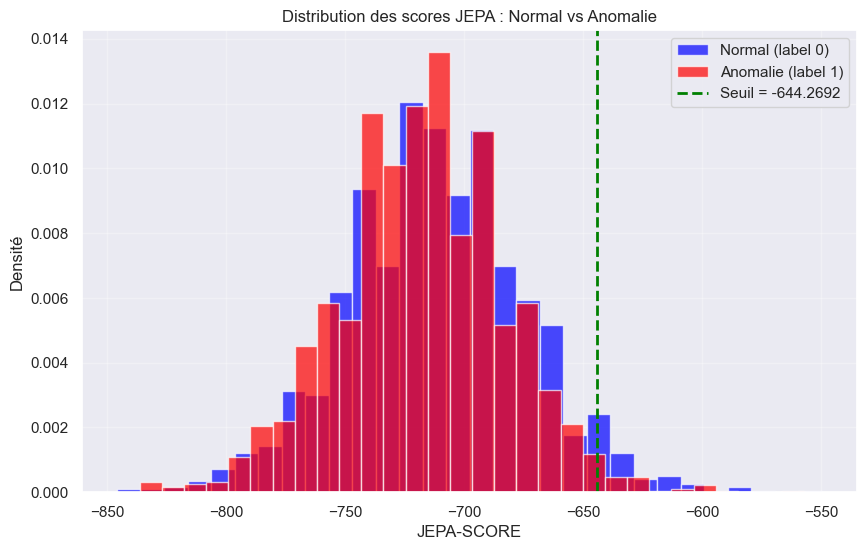

Figure sauvegardée: anomaly_test_results\roc_curve.png


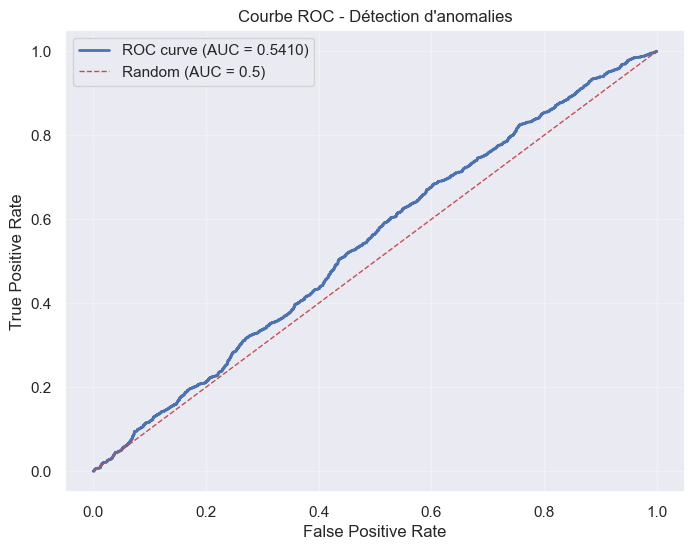

Figure sauvegardée: anomaly_test_results\confusion_matrix.png


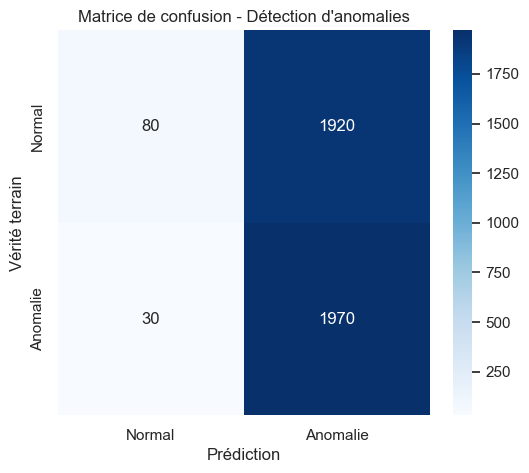

C:\Users\hp\AppData\Local\Temp\ipykernel_11756\2940662695.py:79: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data, labels=['Normal', 'Anomalie'], patch_artist=True)


Figure sauvegardée: anomaly_test_results\boxplot_comparison.png


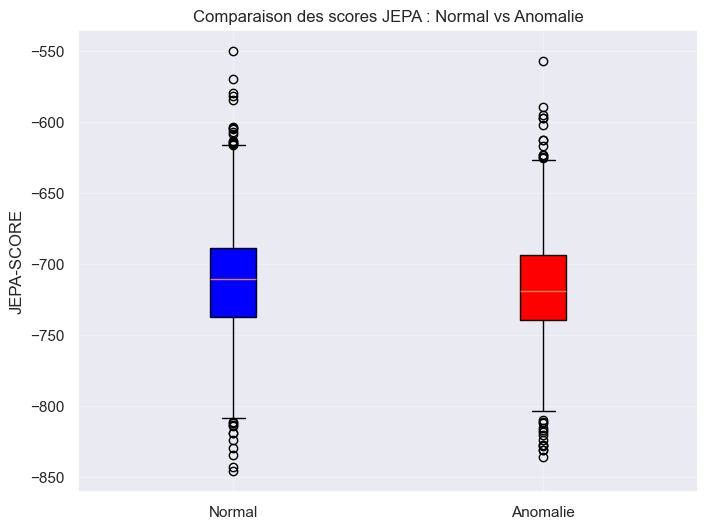


SAUVEGARDE DES RÉSULTATS
Résultats sauvegardés dans: anomaly_test_results
Fichiers créés:
  - score_distribution.png
  - roc_curve.png
  - confusion_matrix.png
  - boxplot_comparison.png
  - scores.csv
  - metrics.csv


In [65]:
results = test_anomaly_detection(
        model_path="model_jepa.keras",  # chemin vers ton modèle
        test_data_loader=df_an,  # ton objet Load_data pour les données de test
        threshold=None,  # seuil automatique
        save_dir="anomaly_test_results"
    )

In [50]:
compute_jepa_score(model.encoder, X_train_an[7])

np.float32(-923.6771)